In [2]:
import torch 
from PIL import Image
from torchvision import transforms
import SIFT
image_to_tensor = transforms.ToTensor()
test = image_to_tensor(Image.open(r"C:\Users\simon\Coding\3DRecon\data\dronesplat\Sculpture\241002_16_001.jpg").convert("L"))
oct = SIFT.create_octaves(test, 6, 6)
dog = SIFT.GetDoG(oct)
extrema = SIFT.ExtremaSearch(dog, 6, 0.03)
for i in extrema:
    print(i.shape)

torch.Size([91, 4])
torch.Size([71, 4])
torch.Size([58, 4])
torch.Size([11, 4])
torch.Size([9, 4])
torch.Size([5, 4])


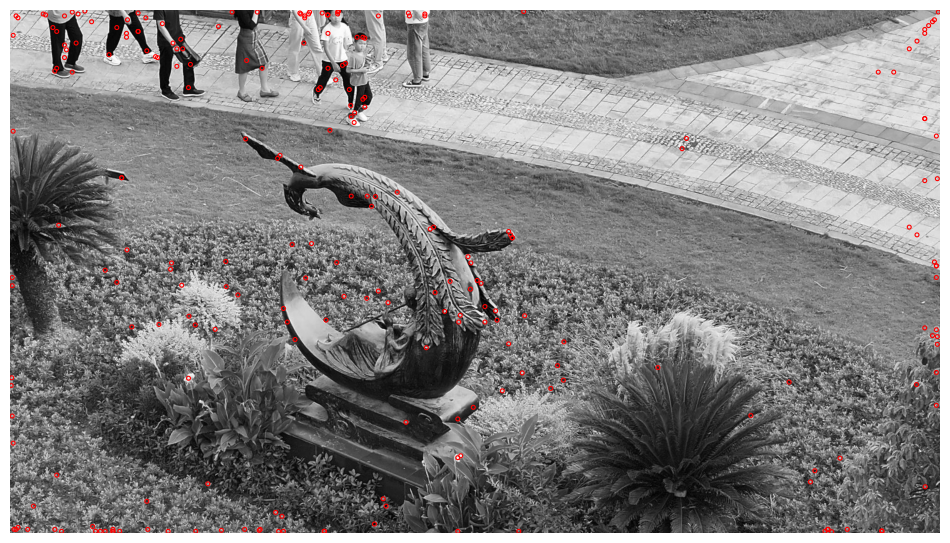

In [3]:
import matplotlib.pyplot as plt

gray = Image.open(r"C:\Users\simon\Coding\3DRecon\data\dronesplat\Sculpture\241002_16_001.jpg").convert("L")

plt.figure(figsize=(12, 8))
plt.imshow(gray, cmap="gray")

# extrema columns are [s, y, x, sigma]; octave o is downsampled by 2**o
for o, pts in enumerate(extrema):
    if len(pts) == 0:
        continue
    scale = 2 ** o
    ys = pts[:, 1].numpy() * scale
    xs = pts[:, 2].numpy() * scale
    plt.scatter(xs, ys, s=8, edgecolors="red", facecolors="none", linewidths=0.8)

plt.axis("off")
plt.show()